In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import HoveringStateEnv, rollout
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import MLP

%matplotlib inline

2025-09-08 19:39:06.000904: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.6 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Training a State-based Quadrotor Policy With BPTT

## Seed it

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=6 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

## Define the Policy Network

In [4]:
policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

In [5]:
N = 1000
scheduler = optax.cosine_decay_schedule(1e-2, N)
tx = optax.adam(scheduler)
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## Initial Rollout

In [6]:
def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    return train_state.apply_fn(train_state.params, obs)

transitions = get_rollouts(env, policy, 10, jax.random.key(3))

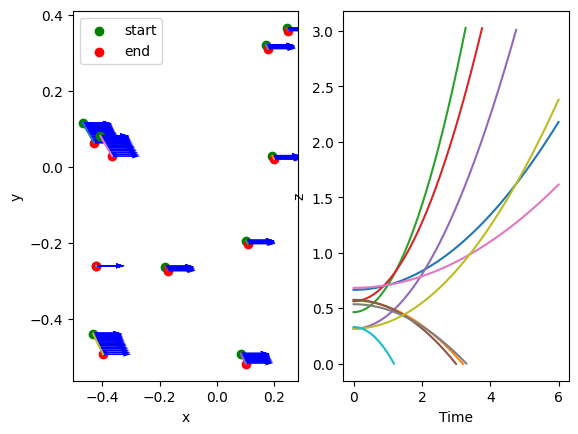

In [7]:
env.plot_trajectories(transitions)

## Train the Policy Using BPTT

In [8]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=1000,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=100,
    key=key_bptt,
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Episode: 0, Grad max: 88.1028
Episode: 0, Loss: 51.42
Episode: 10, Grad max: 31.0928
Episode: 10, Loss: 80.40
Episode: 20, Grad max: 11.2098
Episode: 20, Loss: 77.29
Episode: 30, Grad max: 43.9036
Episode: 30, Loss: 70.10
Episode: 40, Grad max: 21.1863
Episode: 40, Loss: 78.38
Episode: 50, Grad max: 41.0404
Episode: 50, Loss: 64.38
Episode: 60, Grad max: 9.0726
Episode: 60, Loss: 60.01
Episode: 70, Grad max: 16.0618
Episode: 70, Loss: 57.16
Episode: 80, Grad max: 26.8325
Episode: 80, Loss: 54.26
Episode: 90, Grad max: 30.7393
Episode: 90, Loss: 70.02
Episode: 100, Grad max: 24.9563
Episode: 100, Loss: 53.36
Episode: 110, Grad max: 5.7764
Episode: 110, Loss: 47.91
Episode: 120, Grad max: 37.7401
Episode: 120, Loss: 41.77
Episode: 130, Grad max: 55.8767
Episode: 130, Loss: 70.92
Episode: 140, Grad max: 18.8933
Episode: 140, Loss: 53.20
Episode: 150, Grad max: 81.8415
Episode: 150, Loss: 26.41
Episode: 160, Grad max: 49.2246
Episode: 160, Loss: 25.72
Episode: 170, Grad max: 123.8144
Episo

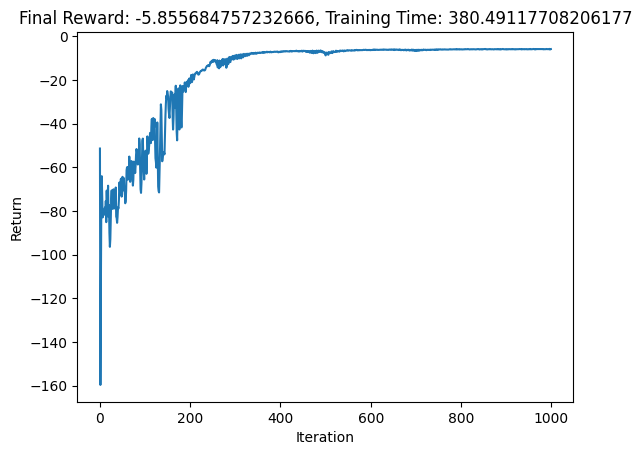

In [9]:
rewards = -res_dict["metrics"]
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [10]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

In [11]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=6 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)
transitions_eval = get_rollouts(env_eval, policy_trained, 1, jax.random.key(3))

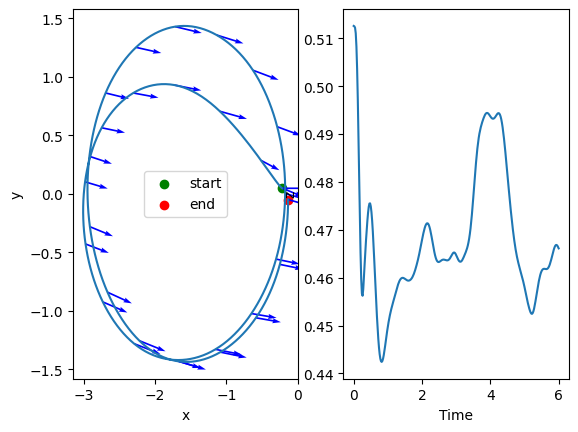

In [12]:
env_eval.plot_trajectories(transitions_eval)

In [13]:
transitions_eval.state.quadrotor_state.initial_p[1][-1,:]

Array([-0.21994066,  0.04672968,  0.51258844], dtype=float32)

In [14]:
transitions_eval.state.quadrotor_state.time_elapsed[1][-1]

Array(5.9997478, dtype=float32, weak_type=True)